In [1]:
import numpy as np

np.random.seed(0)
x = np.random.randn(100, 1)
y = np.sin(2 * np.pi * x) + np.random.rand(100, 1)

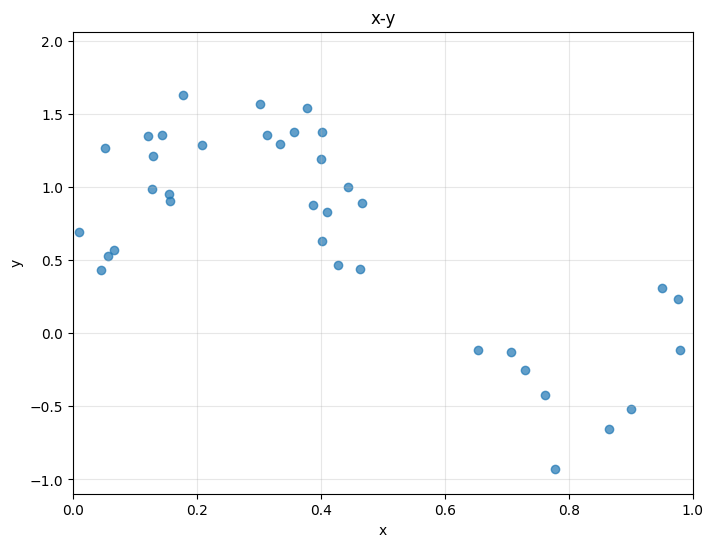

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(x, y, alpha=0.7)
plt.xlabel('x')
plt.ylabel('y')
plt.title('x-y')
plt.xlim(0, 1)
plt.grid(True, alpha=0.3)
plt.show()


In [3]:
import numpy as np
from dezero import Variable
import dezero.functions as F

# 데이터를 Variable로 변환
x_var = Variable(x)
y_var = Variable(y)

I, H, O = 1, 10, 1
W1 = Variable(0.01 * np.random.randn(I, H))
b1 = Variable(np.zeros(H))
W2 = Variable(0.01 * np.random.randn(H, O))
b2 = Variable(np.zeros(O))

def predict(x):
    y = F.linear(x, W1, b1)
    y = F.sigmoid(y)
    y = F.linear(y, W2, b2)
    return y

lr = 0.2
iters = 1_000_000

for i in range(iters):
    y_pred = predict(x_var)
    loss = F.mean_squared_error(y_var, y_pred)
    
    W1.cleargrad()
    b1.cleargrad()
    W2.cleargrad()
    b2.cleargrad()
    loss.backward()
    
    W1.data -= lr * W1.grad.data
    b1.data -= lr * b1.grad.data
    W2.data -= lr * W2.grad.data
    b2.data -= lr * b2.grad.data
    
    if i % 100000 == 0:
        print(loss)
    
    

variable(0.9465288750230947)
variable(0.30922524608241664)
variable(0.06412532886902772)
variable(0.0634485928309756)
variable(0.06304689609795872)
variable(0.06272861185113708)
variable(0.06248740438919776)
variable(0.06229780832880008)
variable(0.06213905280310843)
variable(0.06200328770460329)


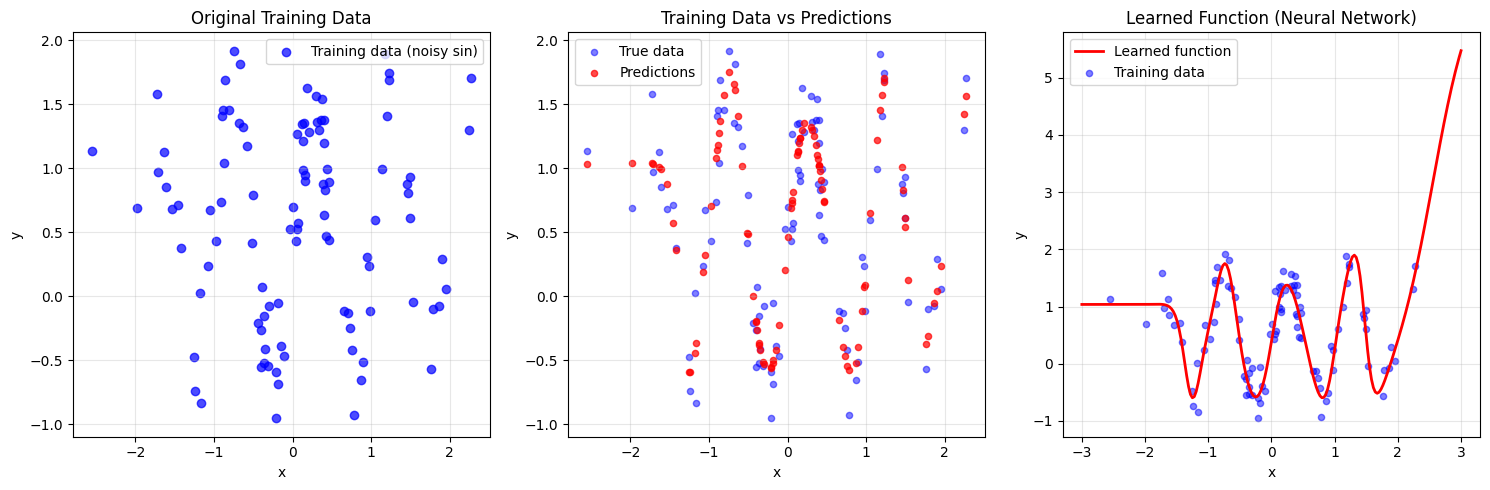

학습된 신경망의 최종 손실: 0.062306


In [4]:
# 학습된 함수의 형태를 보기 위해 연속적인 입력값 생성
x_test = np.linspace(-3, 3, 200).reshape(-1, 1)  # -3부터 3까지 200개 점
x_test_var = Variable(x_test)
y_test_pred = predict(x_test_var)

# 훈련 데이터와 학습된 함수를 함께 시각화
plt.figure(figsize=(15, 5))

# 왼쪽: 원본 데이터 (실제 sin 함수)
plt.subplot(1, 3, 1)
plt.scatter(x, y, alpha=0.7, color='blue', label='Training data (noisy sin)')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Original Training Data')
plt.legend()
plt.grid(True, alpha=0.3)

# 가운데: 훈련 데이터와 예측값 비교
plt.subplot(1, 3, 2)
plt.scatter(x, y, alpha=0.5, color='blue', label='True data', s=20)
y_train_pred = predict(x_var)
plt.scatter(x, y_train_pred.data, alpha=0.7, color='red', label='Predictions', s=20)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Training Data vs Predictions')
plt.legend()
plt.grid(True, alpha=0.3)

# 오른쪽: 학습된 함수의 전체 형태 (hyperplane)
plt.subplot(1, 3, 3)
plt.plot(x_test, y_test_pred.data, 'r-', linewidth=2, label='Learned function')
plt.scatter(x, y, alpha=0.5, color='blue', s=20, label='Training data')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Learned Function (Neural Network)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"학습된 신경망의 최종 손실: {loss.data:.6f}")
